In [1]:
!pip install -q datasets transformers accelerate scikit-learn pandas matplotlib

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

RANDOM_STATE = 42

In [3]:
dataset = load_dataset(
    "FareedKhan/1k_stories_100_genre",
    split="train",
)

df = dataset.to_pandas()

print("Raw shape:", df.shape)
display(df.head())

README.md:   0%|          | 0.00/1.66k [00:00<?, ?B/s]

1k_stories_100_genre.csv:   0%|          | 0.00/5.92M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Raw shape: (1000, 4)


,id,title,story,genre
0,457580,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant s...",Science Fiction
1,297904,Eldoria's Enchanted Whispers,"In a land far away, where the sun shone bright...",Fantasy
2,620436,Echoes of Whispered Shadows,"Once upon a time, in a small, tranquil town ca...",Mystery
3,634687,Emerald Amulet Chronicles Revealed,"Once upon a time in the 16th century, a small ...",Historical Adventure
4,513427,The Shadows of St. Augustine,In the sun-drenched coastal city of St. August...,Thriller


In [4]:
MALFORMED_STORY_ID = "308506"

df["id"] = df["id"].astype(str)

df = (
    df[df["id"] != MALFORMED_STORY_ID]
    .reset_index(drop=True)
)

print("Processed stories:", len(df))
print("Genres:", df["genre"].nunique())
print("Missing stories:", df["story"].isna().sum())
print("Missing genres:", df["genre"].isna().sum())

Processed stories: 999
Genres: 99
Missing stories: 0
Missing genres: 0


In [5]:
df["genre"].value_counts().describe()

,count
count,99.000000
mean,10.090909
std,1.011070
min,9.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,20.000000


In [6]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Model:", MODEL_NAME)
print("Model max length:", tokenizer.model_max_length)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Model: distilbert-base-uncased
Model max length: 512


In [7]:
from tqdm.auto import tqdm

token_lengths = []

for text in tqdm(df["story"], desc="Analyzing story lengths"):
    tokens = tokenizer(
        text,
        add_special_tokens=True,
        truncation=False,
    )

    token_lengths.append(len(tokens["input_ids"]))

token_lengths = np.array(token_lengths)

Analyzing story lengths:   0%|          | 0/999 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1661 > 512). Running this sequence through the model will result in indexing errors


In [8]:
length_stats = {
    "Mean": token_lengths.mean(),
    "Median": np.median(token_lengths),
    "P75": np.percentile(token_lengths, 75),
    "P90": np.percentile(token_lengths, 90),
    "P95": np.percentile(token_lengths, 95),
    "P99": np.percentile(token_lengths, 99),
    "Max": token_lengths.max(),
}

for name, value in length_stats.items():
    print(f"{name:>6}: {value:.1f}")

num_over_512 = (token_lengths > MAX_LENGTH).sum()
pct_over_512 = (token_lengths > MAX_LENGTH).mean() * 100

print()
print(f"Stories > {MAX_LENGTH}: {num_over_512}/{len(df)}")
print(f"Percentage > {MAX_LENGTH}: {pct_over_512:.2f}%")

  Mean: 1204.1
Median: 1193.0
   P75: 1421.0
   P90: 1737.0
   P95: 2002.5
   P99: 2721.4
   Max: 3670.0

Stories > 512: 897/999
Percentage > 512: 89.79%


In [9]:
for threshold in [128, 256, 512, 1024, 2048]:
    count = (token_lengths > threshold).sum()
    percentage = count / len(token_lengths) * 100

    print(
        f"> {threshold:4d} tokens: "
        f"{count:3d} stories ({percentage:5.2f}%)"
    )

>  128 tokens: 997 stories (99.80%)
>  256 tokens: 902 stories (90.29%)
>  512 tokens: 897 stories (89.79%)
> 1024 tokens: 723 stories (72.37%)
> 2048 tokens:  46 stories ( 4.60%)


## Distribution

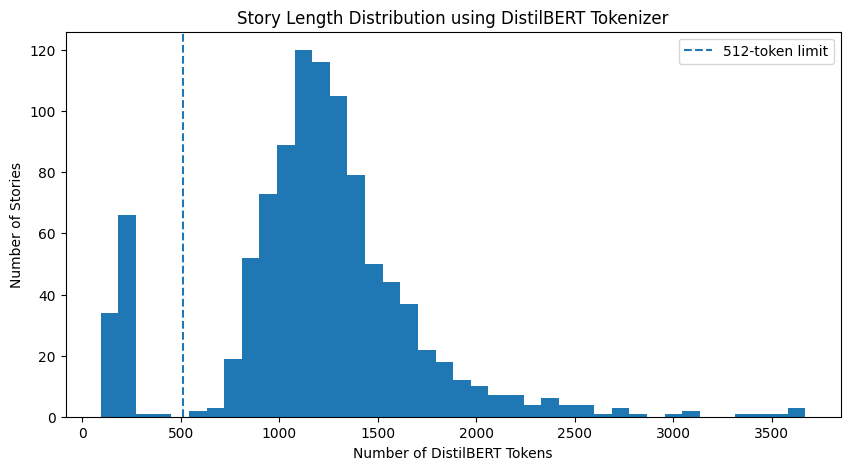

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(token_lengths, bins=40)

plt.axvline(
    MAX_LENGTH,
    linestyle="--",
    label=f"{MAX_LENGTH}-token limit",
)

plt.xlabel("Number of DistilBERT Tokens")
plt.ylabel("Number of Stories")
plt.title("Story Length Distribution using DistilBERT Tokenizer")
plt.legend()
plt.show()

# Experiment 2: DistilBERT + 512 truncation

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["genre"])

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

NUM_LABELS = len(label_encoder.classes_)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Classes:", NUM_LABELS)

print(
    "Train classes:",
    train_df["label"].nunique(),
)

print(
    "Validation classes:",
    val_df["label"].nunique(),
)

Train: 799
Validation: 200
Classes: 99
Train classes: 99
Validation classes: 99


In [12]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["story", "label"]],
    preserve_index=False,
)

val_dataset = Dataset.from_pandas(
    val_df[["story", "label"]],
    preserve_index=False,
)

In [13]:
def tokenize_batch(batch):
    return tokenizer(
        batch["story"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


train_dataset = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["story"],
)

val_dataset = val_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["story"],
)

train_dataset

Map:   0%|          | 0/799 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 799
})

## Load Classifier

In [14]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label={
        i: label
        for i, label in enumerate(label_encoder.classes_)
    },
    label2id={
        label: i
        for i, label in enumerate(label_encoder.classes_)
    },
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Metrics

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0,
        )
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }

## Training config

In [20]:
from transformers import (
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
)

training_args = TrainingArguments(
    output_dir="./distilbert_genre_baseline",

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=10,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=20,

    report_to="none",
    seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics,
)

In [17]:
import torch

print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

Tesla T4


In [21]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,4.008316,3.981445,0.335000,0.222090,0.328283,0.239919,0.242226
2,3.720333,3.718124,0.380000,0.268387,0.373737,0.287273,0.288209
3,3.402062,3.482859,0.455000,0.362833,0.449495,0.369301,0.370314
4,3.185064,3.267785,0.515000,0.446914,0.510101,0.440367,0.442117
5,2.871628,3.086670,0.510000,0.419040,0.505051,0.424374,0.425844
6,2.703562,2.944384,0.555000,0.486516,0.550505,0.479594,0.482071
7,2.540330,2.823806,0.555000,0.481938,0.550505,0.478534,0.481022
8,2.384456,2.754804,0.545000,0.466739,0.540404,0.466910,0.469514
9,2.298873,2.704242,0.560000,0.490308,0.555556,0.487786,0.490180
10,2.347082,2.690891,0.555000,0.488143,0.550505,0.482174,0.484625


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=2.9881797904968264, metrics={'train_runtime': 571.5458, 'train_samples_per_second': 13.98, 'train_steps_per_second': 1.75, 'total_flos': 1060245421332480.0, 'train_loss': 2.9881797904968264, 'epoch': 10.0})

In [22]:
baseline_metrics = trainer.evaluate()

baseline_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
2.347082,2.704242,10,0.560000,0.490308,0.555556,0.487786,0.490180


{'eval_loss': 2.704241991043091,
 'eval_accuracy': 0.56,
 'eval_macro_precision': 0.4903078403078403,
 'eval_macro_recall': 0.5555555555555556,
 'eval_macro_f1': 0.48778550293701806,
 'eval_weighted_f1': 0.49018037518037516}

### Does using information from the entire story improve genre classification compared with truncating the story?

In [26]:
import torch
from torch.utils.data import Dataset

# We reserve space for special tokens.
# For DistilBERT/BERT-style input:
# [CLS] + 510 content tokens + [SEP] = 512
CHUNK_CONTENT_LENGTH = 510


class LongStoryDataset(Dataset):
    def __init__(self, dataframe, tokenizer):
        self.texts = dataframe["story"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenize full story WITHOUT truncation
        token_ids = self.tokenizer(
            text,
            add_special_tokens=False,
            truncation=False,
        )["input_ids"]

        chunks = []

        for start in range(
            0,
            len(token_ids),
            CHUNK_CONTENT_LENGTH,
        ):
            content_ids = token_ids[
                start:start + CHUNK_CONTENT_LENGTH
            ]

            # Add special tokens explicitly
            chunk_ids = [
                self.tokenizer.cls_token_id,
                *content_ids,
                self.tokenizer.sep_token_id,
            ]

            chunks.append(
                torch.tensor(
                    chunk_ids,
                    dtype=torch.long,
                )
            )

        return {
            "chunks": chunks,
            "label": torch.tensor(
                label,
                dtype=torch.long,
            ),
        }

In [27]:
class LongStoryCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch):
        batch_size = len(batch)

        max_chunks = max(
            len(item["chunks"])
            for item in batch
        )

        max_tokens = max(
            len(chunk)
            for item in batch
            for chunk in item["chunks"]
        )

        input_ids = torch.full(
            (batch_size, max_chunks, max_tokens),
            fill_value=self.tokenizer.pad_token_id,
            dtype=torch.long,
        )

        attention_mask = torch.zeros(
            (batch_size, max_chunks, max_tokens),
            dtype=torch.long,
        )

        chunk_mask = torch.zeros(
            (batch_size, max_chunks),
            dtype=torch.float,
        )

        labels = torch.stack(
            [item["label"] for item in batch]
        )

        for i, item in enumerate(batch):
            for j, chunk in enumerate(item["chunks"]):
                length = len(chunk)

                input_ids[i, j, :length] = chunk
                attention_mask[i, j, :length] = 1
                chunk_mask[i, j] = 1

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "chunk_mask": chunk_mask,
            "labels": labels,
        }

In [28]:
long_train_dataset = LongStoryDataset(
    train_df,
    tokenizer,
)

long_val_dataset = LongStoryDataset(
    val_df,
    tokenizer,
)

long_collator = LongStoryCollator(tokenizer)

sample = long_train_dataset[0]

print("Number of chunks:", len(sample["chunks"]))
print("Chunk lengths:", [len(x) for x in sample["chunks"]])
print("Label:", sample["label"])

Number of chunks: 3
Chunk lengths: [512, 512, 497]
Label: tensor(64)


In [29]:
print(type(tokenizer))
print("CLS:", tokenizer.cls_token, tokenizer.cls_token_id)
print("SEP:", tokenizer.sep_token, tokenizer.sep_token_id)
print("PAD:", tokenizer.pad_token, tokenizer.pad_token_id)

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
CLS: [CLS] 101
SEP: [SEP] 102
PAD: [PAD] 0


In [30]:
import torch.nn as nn

from transformers import AutoModel
from transformers.modeling_outputs import SequenceClassifierOutput


class LongTextDistilBERT(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)

        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(0.2)

        self.classifier = nn.Linear(
            hidden_size,
            num_labels,
        )

        self.loss_fn = nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids=None,
        attention_mask=None,
        chunk_mask=None,
        labels=None,
    ):
        batch_size, num_chunks, seq_len = input_ids.shape

        # [B, C, L] -> [B*C, L]
        flat_input_ids = input_ids.view(
            batch_size * num_chunks,
            seq_len,
        )

        flat_attention_mask = attention_mask.view(
            batch_size * num_chunks,
            seq_len,
        )

        outputs = self.encoder(
            input_ids=flat_input_ids,
            attention_mask=flat_attention_mask,
        )

        # First-token representation
        chunk_embeddings = outputs.last_hidden_state[:, 0, :]

        # [B*C, H] -> [B, C, H]
        chunk_embeddings = chunk_embeddings.view(
            batch_size,
            num_chunks,
            -1,
        )

        # Ignore padded chunks during pooling
        mask = chunk_mask.unsqueeze(-1)

        summed = (
            chunk_embeddings * mask
        ).sum(dim=1)

        counts = mask.sum(dim=1).clamp(min=1)

        story_embedding = summed / counts

        logits = self.classifier(
            self.dropout(story_embedding)
        )

        loss = None

        if labels is not None:
            loss = self.loss_fn(
                logits,
                labels,
            )

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
        )

In [31]:
long_model = LongTextDistilBERT(
    MODEL_NAME,
    NUM_LABELS,
)

num_params = sum(
    p.numel()
    for p in long_model.parameters()
)

print(f"Parameters: {num_params / 1e6:.2f}M")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parameters: 66.44M


In [36]:
long_training_args = TrainingArguments(
    output_dir="./distilbert_long_text",

    learning_rate=2e-5,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=4,

    num_train_epochs=10,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    remove_unused_columns=False,

    save_total_limit=2,

    logging_steps=25,

    report_to="none",
    seed=RANDOM_STATE,
)

In [37]:
long_trainer = Trainer(
    model=long_model,
    args=long_training_args,

    train_dataset=long_train_dataset,
    eval_dataset=long_val_dataset,

    data_collator=long_collator,

    compute_metrics=compute_metrics,
)

In [39]:
batch = long_collator([
    long_train_dataset[0],
    long_train_dataset[1],
])

for key, value in batch.items():
    print(key, value.shape)

input_ids torch.Size([2, 3, 512])
attention_mask torch.Size([2, 3, 512])
chunk_mask torch.Size([2, 3])
labels torch.Size([2])


In [40]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

long_model = long_model.to(device)

test_batch = {
    k: v.to(device)
    for k, v in batch.items()
}

with torch.no_grad():
    output = long_model(**test_batch)

print("Loss:", output.loss.item())
print("Logits shape:", output.logits.shape)

Loss: 4.642690658569336
Logits shape: torch.Size([2, 99])


In [41]:
long_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,4.485962,4.331970,0.125000,0.044703,0.121212,0.057261,0.058593
2,3.812097,3.713568,0.340000,0.261183,0.333333,0.264275,0.264299
3,3.249082,3.249963,0.420000,0.332628,0.414141,0.336559,0.336830
4,2.795657,2.916043,0.450000,0.364211,0.444444,0.368264,0.369288
5,2.405109,2.667068,0.505000,0.425615,0.500000,0.426617,0.427684
6,2.153855,2.505099,0.490000,0.423707,0.484848,0.422126,0.423238
7,1.960327,2.385739,0.520000,0.433215,0.515152,0.441400,0.442319
8,1.807648,2.313469,0.550000,0.496633,0.545455,0.494901,0.495667
9,1.597984,2.267389,0.535000,0.489418,0.530303,0.476784,0.477730
10,1.707069,2.254876,0.540000,0.508273,0.535354,0.487799,0.488635


TrainOutput(global_step=1000, training_loss=2.6543476066589355, metrics={'train_runtime': 1898.9945, 'train_samples_per_second': 4.207, 'train_steps_per_second': 0.527, 'total_flos': 0.0, 'train_loss': 2.6543476066589355, 'epoch': 10.0})

In [42]:
long_metrics = long_trainer.evaluate()

long_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1.707069,2.313469,10,0.550000,0.496633,0.545455,0.494901,0.495667


{'eval_loss': 2.3134689331054688,
 'eval_accuracy': 0.55,
 'eval_macro_precision': 0.4966329966329966,
 'eval_macro_recall': 0.5454545454545454,
 'eval_macro_f1': 0.4949013949013949,
 'eval_weighted_f1': 0.49566666666666664}

## Fair comparison between bert and tf-idf

In [43]:
import time
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

# Same exact split used by DistilBERT
X_train = train_df["story"].tolist()
y_train = train_df["label"].to_numpy()

X_val = val_df["story"].tolist()
y_val = val_df["label"].to_numpy()

print("Train stories:", len(X_train))
print("Validation stories:", len(X_val))
print("Train classes:", len(np.unique(y_train)))
print("Validation classes:", len(np.unique(y_val)))

Train stories: 799
Validation stories: 200
Train classes: 99
Validation classes: 99


In [44]:
tfidf_same_split = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=50_000,
    sublinear_tf=True,
)

svc_same_split = LinearSVC(C=1.0)

# Fit TF-IDF ONLY on training data
start = time.perf_counter()

X_train_tfidf = tfidf_same_split.fit_transform(X_train)
svc_same_split.fit(X_train_tfidf, y_train)

train_time = time.perf_counter() - start

# Transform validation using training vocabulary/IDF
X_val_tfidf = tfidf_same_split.transform(X_val)

start = time.perf_counter()

y_pred = svc_same_split.predict(X_val_tfidf)

inference_time = time.perf_counter() - start

accuracy = accuracy_score(y_val, y_pred)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_val,
        y_pred,
        average="macro",
        zero_division=0,
    )
)

_, _, weighted_f1, _ = precision_recall_fscore_support(
    y_val,
    y_pred,
    average="weighted",
    zero_division=0,
)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")

print()
print(f"Training time   : {train_time:.3f} sec")
print(
    f"Inference/story : "
    f"{(inference_time / len(X_val)) * 1000:.3f} ms"
)

Accuracy        : 0.5750
Macro Precision : 0.5286
Macro Recall    : 0.5707
Macro F1        : 0.5202
Weighted F1     : 0.5217

Training time   : 9.103 sec
Inference/story : 0.151 ms


### We started with a strong lexical baseline, investigated whether contextual transformer representations improved classification, identified severe truncation because 89.79% of stories exceeded 512 tokens, then implemented a hierarchical full-story DistilBERT to test that hypothesis. Full-story processing produced only a marginal Macro-F1 improvement over truncation while substantially increasing computational cost. On the same held-out split, TF-IDF + LinearSVC remained stronger and dramatically cheaper, so it was selected as the final classifier.

In [45]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

target_names = label_encoder.classes_

report = classification_report(
    y_val,
    y_pred,
    labels=np.arange(len(target_names)),
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).T

display(
    report_df
    .iloc[:len(target_names)]
    .sort_values("f1-score")
)

cm = confusion_matrix(
    y_val,
    y_pred,
    labels=np.arange(len(target_names)),
)

print("Confusion matrix shape:", cm.shape)

,precision,recall,f1-score,support
Alternate Reality,0.0,0.0,0.0,2.0
Alternate History,0.0,0.0,0.0,2.0
Apocalyptic,0.0,0.0,0.0,2.0
Fantasy,0.0,0.0,0.0,2.0
Folklore,0.0,0.0,0.0,2.0
...,...,...,...,...
Time-Loop,1.0,1.0,1.0,2.0
Superhero,1.0,1.0,1.0,2.0
Virtual Reality,1.0,1.0,1.0,2.0
War Comedy,1.0,1.0,1.0,2.0


Confusion matrix shape: (99, 99)


In [46]:
confusions = []

for true_idx in range(len(target_names)):
    for pred_idx in range(len(target_names)):

        if true_idx == pred_idx:
            continue

        count = cm[true_idx, pred_idx]

        if count > 0:
            confusions.append({
                "true_genre": target_names[true_idx],
                "predicted_genre": target_names[pred_idx],
                "count": int(count),
            })

confusions_df = (
    pd.DataFrame(confusions)
    .sort_values(
        "count",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(confusions_df.head(25))

,true_genre,predicted_genre,count
0,Apocalyptic,Post-Apocalyptic,2
1,Science Fiction,Space Exploration,2
2,Space Opera,Space Thriller,2
3,Horror,Paranormal,2
4,Romantic Fantasy,Fairy Tale,2
5,Adventure,Folklore,1
6,Alternate History,Espionage,1
7,Alternate Dimension,Multiverse,1
8,Animal Fiction,Animal Fantasy,1
9,Anthology,Suburban Drama,1


### Error analysis showed that many of the most frequent confusions occurred between semantically related or narratively overlapping genres, such as Apocalyptic/Post-Apocalyptic, Horror/Paranormal, and Space Opera/Space Thriller. However, some less intuitive errors remained, indicating that label overlap is not the only source of classification error.

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
import joblib
import os

final_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=50_000,
    sublinear_tf=True,
)

final_svc = LinearSVC(C=1.0)

X_full = df["story"].tolist()
y_full = df["label"].to_numpy()

X_full_tfidf = final_tfidf.fit_transform(X_full)
final_svc.fit(X_full_tfidf, y_full)

print("Final training stories:", len(X_full))
print("Vocabulary size:", len(final_tfidf.vocabulary_))

Final training stories: 999
Vocabulary size: 50000


In [48]:
ARTIFACT_DIR = "/content/task2_final_model"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(
    final_tfidf,
    f"{ARTIFACT_DIR}/tfidf_vectorizer.joblib"
)

joblib.dump(
    final_svc,
    f"{ARTIFACT_DIR}/linear_svc.joblib"
)

joblib.dump(
    label_encoder,
    f"{ARTIFACT_DIR}/label_encoder.joblib"
)

print("Saved:")
for file in os.listdir(ARTIFACT_DIR):
    print(" -", file)

Saved:
 - tfidf_vectorizer.joblib
 - label_encoder.joblib
 - linear_svc.joblib


In [49]:
import shutil

shutil.make_archive(
    "/content/task2_final_model",
    "zip",
    "/content/task2_final_model",
)

print("Created: /content/task2_final_model.zip")

Created: /content/task2_final_model.zip


In [50]:
from google.colab import files

files.download("/content/task2_final_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Experiment 4: Qwen3-4B + QLoRA Genre Classification

In [51]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

    props = torch.cuda.get_device_properties(0)

    print(
        f"VRAM: {props.total_memory / 1024**3:.2f} GB"
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 14.56 GB


In [52]:
!nvidia-smi

Thu Oct  1 09:32:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             33W /   70W |    7783MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [53]:
import gc
import torch

# Remove DistilBERT training objects from GPU memory
for name in [
    "long_trainer",
    "long_model",
    "model",
    "trainer",
]:
    if name in globals():
        del globals()[name]

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(
    f"Allocated: "
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

print(
    f"Reserved: "
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

Allocated: 0.79 GB
Reserved: 0.92 GB


In [54]:
!nvidia-smi

Thu Oct  1 09:33:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             33W /   70W |    1077MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [55]:
!pip install -q -U \
    transformers \
    peft \
    accelerate \
    bitsandbytes \
    trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 835.4/835.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 51.8 MB/s eta 0:00:00


In [56]:
import transformers
import peft
import accelerate
import bitsandbytes as bnb
import trl

print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("accelerate:", accelerate.__version__)
print("bitsandbytes:", bnb.__version__)
print("trl:", trl.__version__)

transformers: 5.16.1
peft: 0.20.0
accelerate: 1.14.0
bitsandbytes: 0.50.2
trl: 1.14.1


## Load tokenizer + 4-bit base model

In [57]:
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

QWEN_MODEL_NAME = "Qwen/Qwen3-4B"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,

    # QLoRA-style quantization
    bnb_4bit_quant_type="nf4",

    # T4 -> FP16 compute
    bnb_4bit_compute_dtype=torch.float16,

    # Additional memory saving
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(
    QWEN_MODEL_NAME,
    use_fast=True,
)

# Qwen normally already has a pad token configuration,
# but keep this safe for batching.
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

qwen_model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

print("Model loaded.")
print("Model:", QWEN_MODEL_NAME)
print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)
print(
    "Memory allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB",
)
print(
    "Memory reserved:",
    round(torch.cuda.memory_reserved() / 1024**3, 2),
    "GB",
)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model loaded.
Model: Qwen/Qwen3-4B
Pad token: <|endoftext|>
EOS token: <|im_end|>
Memory allocated: 3.29 GB
Memory reserved: 3.34 GB


In [58]:
!nvidia-smi

Thu Oct  1 09:39:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             33W /   70W |    3559MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Training Prompt and Token Length

In [59]:
GENRES = list(label_encoder.classes_)

print("Number of genres:", len(GENRES))
print(GENRES[:10])

Number of genres: 99
['Adventure', 'Alternate Dimension', 'Alternate History', 'Alternate Reality', 'Animal Fantasy', 'Animal Fiction', 'Anthology', 'Apocalyptic', 'Apocalyptic Comedy', 'Artificial Intelligence']


In [60]:
def build_genre_messages(story, genre=None):
    system_message = (
        "You are a story genre classifier. "
        "Classify the story into exactly one of the allowed genres. "
        "Return only the genre name and nothing else."
    )

    user_message = (
        "Allowed genres:\n"
        + ", ".join(GENRES)
        + "\n\nStory:\n"
        + story
    )

    messages = [
        {
            "role": "system",
            "content": system_message,
        },
        {
            "role": "user",
            "content": user_message,
        },
    ]

    if genre is not None:
        messages.append(
            {
                "role": "assistant",
                "content": genre,
            }
        )

    return messages

In [61]:
example_messages = build_genre_messages(
    train_df.iloc[0]["story"],
    label_encoder.inverse_transform(
        [train_df.iloc[0]["label"]]
    )[0],
)

for message in example_messages:
    print("=" * 80)
    print(message["role"].upper())
    print(message["content"][:1000])

SYSTEM
You are a story genre classifier. Classify the story into exactly one of the allowed genres. Return only the genre name and nothing else.
USER
Allowed genres:
Adventure, Alternate Dimension, Alternate History, Alternate Reality, Animal Fantasy, Animal Fiction, Anthology, Apocalyptic, Apocalyptic Comedy, Artificial Intelligence, Artistic Drama, Biographical, Comedy, Coming-of-Age, Coming-of-Middle-Age, Crime, Cyberpunk, Detective Fiction, Disaster, Domestic Fiction, Dreamlike, Dystopian, Environmental, Espionage, Evolutionary Fiction, Existential Drama, Experimental, Fairy Tale, Family Drama, Fantasy, Folklore, Futuristic, Generation Gap, Gothic, Hard Science Fiction, Historical Adventure, Historical Fiction, Historical Romance, Horror, Humor, Inspirational, Legal Drama, Magical Girl, Magical Realism, Medical Drama, Medical Mystery, Military Fiction, Multiverse, Mystery, Mystery Comedy, Mystery Thriller, Mythic Fiction, Mythology, Nautical Fiction, Noir, Noir Comedy, Paranormal, 

In [62]:
def format_training_example(row):
    genre = label_encoder.inverse_transform(
        [int(row["label"])]
    )[0]

    messages = build_genre_messages(
        row["story"],
        genre,
    )

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
        enable_thinking=False,
    )

In [63]:
sample_text = format_training_example(
    train_df.iloc[0]
)

print(sample_text[:2000])

<|im_start|>system
You are a story genre classifier. Classify the story into exactly one of the allowed genres. Return only the genre name and nothing else.<|im_end|>
<|im_start|>user
Allowed genres:
Adventure, Alternate Dimension, Alternate History, Alternate Reality, Animal Fantasy, Animal Fiction, Anthology, Apocalyptic, Apocalyptic Comedy, Artificial Intelligence, Artistic Drama, Biographical, Comedy, Coming-of-Age, Coming-of-Middle-Age, Crime, Cyberpunk, Detective Fiction, Disaster, Domestic Fiction, Dreamlike, Dystopian, Environmental, Espionage, Evolutionary Fiction, Existential Drama, Experimental, Fairy Tale, Family Drama, Fantasy, Folklore, Futuristic, Generation Gap, Gothic, Hard Science Fiction, Historical Adventure, Historical Fiction, Historical Romance, Horror, Humor, Inspirational, Legal Drama, Magical Girl, Magical Realism, Medical Drama, Medical Mystery, Military Fiction, Multiverse, Mystery, Mystery Comedy, Mystery Thriller, Mythic Fiction, Mythology, Nautical Fictio

# Token-length Analysis

In [64]:
import numpy as np

train_lengths = []

for _, row in train_df.iterrows():
    text = format_training_example(row)

    ids = tokenizer(
        text,
        add_special_tokens=False,
        truncation=False,
    )["input_ids"]

    train_lengths.append(len(ids))

train_lengths = np.array(train_lengths)

print(f"Mean   : {train_lengths.mean():.1f}")
print(f"Median : {np.median(train_lengths):.1f}")
print(f"P75    : {np.percentile(train_lengths, 75):.1f}")
print(f"P90    : {np.percentile(train_lengths, 90):.1f}")
print(f"P95    : {np.percentile(train_lengths, 95):.1f}")
print(f"P99    : {np.percentile(train_lengths, 99):.1f}")
print(f"Max    : {train_lengths.max()}")

for limit in [1024, 1536, 2048, 2560, 3072, 4096]:
    count = (train_lengths > limit).sum()

    print(
        f">{limit}: "
        f"{count}/{len(train_lengths)} "
        f"({count / len(train_lengths) * 100:.2f}%)"
    )

Mean   : 1593.9
Median : 1592.0
P75    : 1823.5
P90    : 2125.4
P95    : 2388.8
P99    : 3178.7
Max    : 4056
>1024: 714/799 (89.36%)
>1536: 467/799 (58.45%)
>2048: 101/799 (12.64%)
>2560: 29/799 (3.63%)
>3072: 11/799 (1.38%)
>4096: 0/799 (0.00%)


### A 2,048-token training context was selected based on the empirical prompt-length distribution, covering 87.36% of training examples without truncation while balancing memory and compute constraints on a 15 GB Tesla T4.

# Prepare Qwen for QLoRA

In [65]:
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)

qwen_model = prepare_model_for_kbit_training(
    qwen_model,
    use_gradient_checkpointing=True,
)

qwen_model.config.use_cache = False

In [66]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,

    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    lora_dropout=0.05,

    bias="none",

    task_type="CAUSAL_LM",
)

In [67]:
qwen_model = get_peft_model(
    qwen_model,
    lora_config,
)

qwen_model.print_trainable_parameters()

trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


In [71]:
import numpy as np
from torch.utils.data import Dataset

MAX_LENGTH = 2048


class GenreSFTDataset(Dataset):
    def __init__(
        self,
        dataframe,
        tokenizer,
        label_encoder,
        max_length=2048,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.label_encoder = label_encoder
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        story = row["story"]

        genre = self.label_encoder.inverse_transform(
            [int(row["label"])]
        )[0]

        # --------------------------------------------------
        # 1. Build a placeholder version to measure
        #    everything EXCEPT the story.
        # --------------------------------------------------

        placeholder = "__STORY_PLACEHOLDER__"

        placeholder_messages = build_genre_messages(
            placeholder,
            genre,
        )

        placeholder_text = self.tokenizer.apply_chat_template(
            placeholder_messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False,
        )

        placeholder_ids = self.tokenizer(
            placeholder_text,
            add_special_tokens=False,
        )["input_ids"]

        placeholder_story_ids = self.tokenizer(
            placeholder,
            add_special_tokens=False,
        )["input_ids"]

        fixed_token_count = (
            len(placeholder_ids)
            - len(placeholder_story_ids)
        )

        # --------------------------------------------------
        # 2. Calculate how many story tokens can fit
        # --------------------------------------------------

        max_story_tokens = (
            self.max_length
            - fixed_token_count
        )

        if max_story_tokens <= 0:
            raise ValueError(
                "Prompt overhead exceeds MAX_LENGTH."
            )

        # --------------------------------------------------
        # 3. Tokenize + truncate ONLY the story
        # --------------------------------------------------

        story_ids = self.tokenizer(
            story,
            add_special_tokens=False,
            truncation=False,
        )["input_ids"]

        story_ids = story_ids[:max_story_tokens]

        truncated_story = self.tokenizer.decode(
            story_ids,
            skip_special_tokens=True,
        )

        # --------------------------------------------------
        # 4. Build final prompt WITHOUT answer
        # --------------------------------------------------

        prompt_messages = build_genre_messages(
            truncated_story,
            genre=None,
        )

        prompt_text = self.tokenizer.apply_chat_template(
            prompt_messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )

        # --------------------------------------------------
        # 5. Build full training sequence WITH answer
        # --------------------------------------------------

        full_messages = build_genre_messages(
            truncated_story,
            genre=genre,
        )

        full_text = self.tokenizer.apply_chat_template(
            full_messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False,
        )

        prompt_ids = self.tokenizer(
            prompt_text,
            add_special_tokens=False,
        )["input_ids"]

        full_encoding = self.tokenizer(
            full_text,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length,
        )

        input_ids = full_encoding["input_ids"]
        attention_mask = full_encoding["attention_mask"]

        # --------------------------------------------------
        # 6. Assistant-only loss
        # --------------------------------------------------

        labels = input_ids.copy()

        prompt_length = min(
            len(prompt_ids),
            len(labels),
        )

        labels[:prompt_length] = (
            [-100] * prompt_length
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [73]:
qwen_train_dataset = GenreSFTDataset(
    train_df,
    tokenizer,
    label_encoder,
    MAX_LENGTH,
)

qwen_val_dataset = GenreSFTDataset(
    val_df,
    tokenizer,
    label_encoder,
    MAX_LENGTH,
)

## Sanity Check

In [74]:
import numpy as np

target_token_counts = []
bad_examples = []

for i in range(len(qwen_train_dataset)):
    item = qwen_train_dataset[i]

    labels = np.array(item["labels"])

    target_count = int((labels != -100).sum())
    target_token_counts.append(target_count)

    if target_count == 0:
        bad_examples.append(i)

print("Target-token statistics")
print("-----------------------")
print("Min   :", np.min(target_token_counts))
print("Median:", np.median(target_token_counts))
print("Max   :", np.max(target_token_counts))

print()
print("Examples with ZERO supervised tokens:")
print(len(bad_examples))

print("First bad indices:", bad_examples[:20])

Target-token statistics
-----------------------
Min   : 3
Median: 5.0
Max   : 8

Examples with ZERO supervised tokens:
0
First bad indices: []


In [75]:
import torch


class GenreDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        max_len = max(
            len(f["input_ids"])
            for f in features
        )

        input_ids = []
        attention_masks = []
        labels = []

        for f in features:
            pad_len = max_len - len(f["input_ids"])

            input_ids.append(
                f["input_ids"]
                + [self.tokenizer.pad_token_id] * pad_len
            )

            attention_masks.append(
                f["attention_mask"]
                + [0] * pad_len
            )

            labels.append(
                f["labels"]
                + [-100] * pad_len
            )

        return {
            "input_ids": torch.tensor(
                input_ids,
                dtype=torch.long,
            ),
            "attention_mask": torch.tensor(
                attention_masks,
                dtype=torch.long,
            ),
            "labels": torch.tensor(
                labels,
                dtype=torch.long,
            ),
        }


qwen_collator = GenreDataCollator(tokenizer)

In [76]:
test_batch = qwen_collator([
    qwen_train_dataset[0],
    qwen_train_dataset[1],
])

print("input_ids:", test_batch["input_ids"].shape)
print("attention_mask:", test_batch["attention_mask"].shape)
print("labels:", test_batch["labels"].shape)

print(
    "Supervised tokens:",
    (test_batch["labels"] != -100).sum(dim=1)
)

input_ids: torch.Size([2, 1871])
attention_mask: torch.Size([2, 1871])
labels: torch.Size([2, 1871])
Supervised tokens: tensor([5, 4])


In [78]:
from transformers import TrainingArguments

QWEN_OUTPUT_DIR = "./qwen3_4b_genre_qlora"

training_args = TrainingArguments(
    output_dir=QWEN_OUTPUT_DIR,

    num_train_epochs=3,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    # Effective batch size ≈ 8
    gradient_accumulation_steps=8,

    learning_rate=1e-4,

    lr_scheduler_type="cosine",
    warmup_steps=15,

    weight_decay=0.01,

    # Tesla T4
    fp16=True,
    bf16=False,

    gradient_checkpointing=True,

    remove_unused_columns=False,

    logging_steps=20,

    save_strategy="epoch",
    save_total_limit=2,

    report_to="none",
    seed=42,
)

In [79]:
from transformers import Trainer

qwen_trainer = Trainer(
    model=qwen_model,
    args=training_args,
    train_dataset=qwen_train_dataset,
    data_collator=qwen_collator,
)

print("Trainer created successfully.")

Trainer created successfully.


In [80]:
!nvidia-smi

Thu Oct  1 09:54:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             32W /   70W |    5169MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [81]:
import time
import torch

torch.cuda.reset_peak_memory_stats()

start_time = time.time()

train_result = qwen_trainer.train()

training_time = time.time() - start_time
peak_vram_gb = torch.cuda.max_memory_allocated() / 1024**3

print("\n" + "=" * 60)
print(f"Training time : {training_time / 60:.2f} minutes")
print(f"Peak VRAM     : {peak_vram_gb:.2f} GB")
print("=" * 60)

print(train_result)

Step,Training Loss
20,1.657291
40,0.472061
60,0.403633
80,0.364901
100,0.317132


KeyboardInterrupt: 

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
import shutil
import os

src = "/content/qwen3_4b_genre_qlora/checkpoint-100"
dst = "/content/drive/MyDrive/story_dataset_ai_system/qwen_qlora/checkpoint-100"

os.makedirs(os.path.dirname(dst), exist_ok=True)

shutil.copytree(
    src,
    dst,
    dirs_exist_ok=True,
)

print("Checkpoint safely backed up to Drive.")

Checkpoint safely backed up to Drive.


In [84]:
!du -sh /content/drive/MyDrive/story_dataset_ai_system/qwen_qlora/checkpoint-100
!ls -lh /content/drive/MyDrive/story_dataset_ai_system/qwen_qlora/checkpoint-100

390M	/content/drive/MyDrive/story_dataset_ai_system/qwen_qlora/checkpoint-100
total 390M
-rw------- 1 root root 1.2K Oct  1 11:30 adapter_config.json
-rw------- 1 root root 127M Oct  1 11:30 adapter_model.safetensors
-rw------- 1 root root 4.1K Oct  1 11:30 chat_template.jinja
-rw------- 1 root root 253M Oct  1 11:30 optimizer.pt
-rw------- 1 root root 5.1K Oct  1 11:30 README.md
-rw------- 1 root root  15K Oct  1 11:30 rng_state.pth
-rw------- 1 root root 1.4K Oct  1 11:30 scaler.pt
-rw------- 1 root root 1.5K Oct  1 11:30 scheduler.pt
-rw------- 1 root root  694 Oct  1 11:30 tokenizer_config.json
-rw------- 1 root root  11M Oct  1 11:30 tokenizer.json
-rw------- 1 root root 1.7K Oct  1 11:30 trainer_state.json
-rw------- 1 root root 5.1K Oct  1 11:30 training_args.bin


# TEsting after one epoch

In [85]:
from peft import PeftModel
import gc
import torch

# Remove the interrupted in-memory PEFT model
if "qwen_model" in globals():
    del qwen_model

if "qwen_trainer" in globals():
    del qwen_trainer

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU allocated:",
    torch.cuda.memory_allocated() / 1024**3,
    "GB"
)

GPU allocated: 3.7685770988464355 GB


In [86]:
from transformers import (
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import PeftModel

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-4B",
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

checkpoint_path = (
    "/content/drive/MyDrive/"
    "story_dataset_ai_system/qwen_qlora/checkpoint-100"
)

eval_model = PeftModel.from_pretrained(
    base_model,
    checkpoint_path,
)

eval_model.eval()

print("Checkpoint-100 loaded successfully.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Checkpoint-100 loaded successfully.


In [87]:
def build_eval_prompt(story):
    messages = build_genre_messages(
        story=story,
        genre=None,
    )

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

In [88]:
MAX_LENGTH = 2048

def build_safe_eval_prompt(story):
    # Measure fixed prompt overhead using placeholder
    placeholder = "__STORY_PLACEHOLDER__"

    placeholder_prompt = build_eval_prompt(placeholder)

    placeholder_ids = tokenizer(
        placeholder_prompt,
        add_special_tokens=False,
    )["input_ids"]

    placeholder_story_ids = tokenizer(
        placeholder,
        add_special_tokens=False,
    )["input_ids"]

    fixed_tokens = (
        len(placeholder_ids)
        - len(placeholder_story_ids)
    )

    # Leave a small safety margin
    max_story_tokens = MAX_LENGTH - fixed_tokens - 8

    story_ids = tokenizer(
        story,
        add_special_tokens=False,
        truncation=False,
    )["input_ids"]

    story_ids = story_ids[:max_story_tokens]

    safe_story = tokenizer.decode(
        story_ids,
        skip_special_tokens=True,
    )

    return build_eval_prompt(safe_story)

In [89]:
for i in range(3):
    row = val_df.iloc[i]

    prompt = build_safe_eval_prompt(row["story"])

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(eval_model.device)

    with torch.no_grad():
        outputs = eval_model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]

    prediction = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    ).strip()

    true_genre = label_encoder.inverse_transform(
        [int(row["label"])]
    )[0]

    print("=" * 80)
    print("TRUE :", true_genre)
    print("PRED :", repr(prediction))

TRUE : Steampunk Fantasy
PRED : 'Steampunk Fantasy'
TRUE : Multiverse
PRED : 'Multiverse'
TRUE : Technological Thriller
PRED : 'Techno-Mystery'


In [90]:
import time
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

predictions = []
true_labels = []
latencies = []
raw_predictions = []

valid_genres = set(GENRES)

eval_model.eval()

start_total = time.time()

for i, row in val_df.reset_index(drop=True).iterrows():

    prompt = build_safe_eval_prompt(row["story"])

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=False,
    ).to(eval_model.device)

    torch.cuda.synchronize()
    start = time.time()

    with torch.no_grad():
        outputs = eval_model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    torch.cuda.synchronize()

    latency = time.time() - start

    generated_ids = outputs[
        0,
        inputs["input_ids"].shape[1]:
    ]

    pred = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    ).strip()

    true_genre = label_encoder.inverse_transform(
        [int(row["label"])]
    )[0]

    raw_predictions.append(pred)
    predictions.append(pred)
    true_labels.append(true_genre)
    latencies.append(latency)

    if (i + 1) % 20 == 0:
        print(
            f"{i+1:3d}/200 | "
            f"running accuracy = "
            f"{accuracy_score(true_labels, predictions):.4f}"
        )

total_time = time.time() - start_total

 20/200 | running accuracy = 0.6000
 40/200 | running accuracy = 0.6250
 60/200 | running accuracy = 0.6000
 80/200 | running accuracy = 0.6375
100/200 | running accuracy = 0.6600
120/200 | running accuracy = 0.6667
140/200 | running accuracy = 0.6357
160/200 | running accuracy = 0.6500
180/200 | running accuracy = 0.6500
200/200 | running accuracy = 0.6450


In [91]:
accuracy = accuracy_score(
    true_labels,
    predictions,
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        true_labels,
        predictions,
        labels=GENRES,
        average="macro",
        zero_division=0,
    )
)

_, _, weighted_f1, _ = (
    precision_recall_fscore_support(
        true_labels,
        predictions,
        labels=GENRES,
        average="weighted",
        zero_division=0,
    )
)

invalid_predictions = [
    p for p in predictions
    if p not in valid_genres
]

print("\n" + "=" * 60)
print("Qwen3-4B QLoRA — Checkpoint 100 / Epoch 1")
print("=" * 60)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")

print()
print(
    f"Invalid outputs : "
    f"{len(invalid_predictions)}/{len(predictions)}"
)

print(
    f"Avg latency     : "
    f"{np.mean(latencies):.3f} sec/story"
)

print(
    f"Total eval time : "
    f"{total_time / 60:.2f} minutes"
)


Qwen3-4B QLoRA — Checkpoint 100 / Epoch 1
Accuracy        : 0.6450
Macro Precision : 0.6311
Macro Recall    : 0.6490
Macro F1        : 0.6077
Weighted F1     : 0.6056

Invalid outputs : 5/200
Avg latency     : 2.553 sec/story
Total eval time : 8.56 minutes


In [92]:
qwen_epoch1_results = pd.DataFrame({
    "true_genre": true_labels,
    "predicted_genre": predictions,
    "correct": np.array(true_labels) == np.array(predictions),
    "latency_sec": latencies,
})

qwen_epoch1_results.to_csv(
    "/content/qwen_epoch1_validation_predictions.csv",
    index=False,
)

qwen_epoch1_results.head()

,true_genre,predicted_genre,correct,latency_sec
0,Steampunk Fantasy,Steampunk Fantasy,True,3.429871
1,Multiverse,Multiverse,True,2.952550
2,Technological Thriller,Techno-Mystery,False,2.864717
3,War,Post-Apocalyptic,False,4.455769
4,Space Opera,Space Thriller,False,2.555759


In [93]:
print("Invalid predictions:")
print("-" * 80)

for i, (true, pred) in enumerate(
    zip(true_labels, predictions)
):
    if pred not in valid_genres:
        print(f"TRUE : {true}")
        print(f"PRED : {repr(pred)}")
        print("-" * 80)

Invalid predictions:
--------------------------------------------------------------------------------
TRUE : Supernatural Drama
PRED : 'Mystic Fiction'
--------------------------------------------------------------------------------
TRUE : Humor
PRED : 'Culinary Comedy'
--------------------------------------------------------------------------------
TRUE : Paranormal
PRED : 'Paranormal Comedy'
--------------------------------------------------------------------------------
TRUE : Slice of Life
PRED : 'Community Drama'
--------------------------------------------------------------------------------
TRUE : Experimental
PRED : 'Colorful Fantasy'
--------------------------------------------------------------------------------


In [94]:
CHECKPOINT_PATH = (
    "/content/drive/MyDrive/"
    "story_dataset_ai_system/qwen_qlora/checkpoint-100"
)

import os

print("Exists:", os.path.exists(CHECKPOINT_PATH))
print(os.listdir(CHECKPOINT_PATH))

Exists: True
['training_args.bin', 'adapter_config.json', 'README.md', 'adapter_model.safetensors', 'optimizer.pt', 'scheduler.pt', 'trainer_state.json', 'scaler.pt', 'tokenizer_config.json', 'tokenizer.json', 'rng_state.pth', 'chat_template.jinja']


In [95]:
for name in [
    "qwen_model",
    "eval_model",
    "base_model",
    "qwen_trainer",
    "train_dataset",
    "val_df",
    "tokenizer",
]:
    print(f"{name:15s}:", name in globals())

qwen_model     : False
eval_model     : True
base_model     : True
qwen_trainer   : False
train_dataset  : True
val_df         : True
tokenizer      : True


In [96]:
from transformers import TrainingArguments, Trainer
import torch
import time

CHECKPOINT_PATH = (
    "/content/drive/MyDrive/"
    "story_dataset_ai_system/qwen_qlora/checkpoint-100"
)

OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "story_dataset_ai_system/qwen_qlora/resumed_training"
)

# This is already the PEFT model loaded from checkpoint-100
qwen_model = eval_model

qwen_model.train()
qwen_model.config.use_cache = False

training_args_resume = TrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=3,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=15,
    weight_decay=0.01,

    fp16=True,
    bf16=False,

    gradient_checkpointing=True,
    remove_unused_columns=False,

    logging_steps=20,

    # More interruption-safe than save_strategy="epoch"
    save_strategy="steps",
    save_steps=25,
    save_total_limit=4,

    report_to="none",
    seed=42,
)


print("Trainer ready.")
print("Resume from:", CHECKPOINT_PATH)
print("New checkpoints:", OUTPUT_DIR)

Trainer ready.
Resume from: /content/drive/MyDrive/story_dataset_ai_system/qwen_qlora/checkpoint-100
New checkpoints: /content/drive/MyDrive/story_dataset_ai_system/qwen_qlora/resumed_training


In [97]:
qwen_trainer.args.num_train_epochs = 2

In [98]:
print("Target epochs:", qwen_trainer.args.num_train_epochs)
print("Resume checkpoint:", CHECKPOINT_PATH)

Target epochs: 2
Resume checkpoint: /content/drive/MyDrive/story_dataset_ai_system/qwen_qlora/checkpoint-100


In [100]:
eval_model.print_trainable_parameters()

trainable = [
    (name, p.numel())
    for name, p in eval_model.named_parameters()
    if p.requires_grad
]

print("Trainable tensors:", len(trainable))
print(
    "Trainable parameters:",
    sum(n for _, n in trainable)
)

trainable params: 0 || all params: 4,055,498,240 || trainable%: 0.0000
Trainable tensors: 0
Trainable parameters: 0


In [101]:
eval_model.set_adapter("default")

for name, param in eval_model.named_parameters():
    if "lora_" in name:
        param.requires_grad = True

eval_model.train()
eval_model.config.use_cache = False

eval_model.print_trainable_parameters()

trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


In [102]:
from transformers import TrainingArguments, Trainer

OUTPUT_DIR = (
    "/content/drive/MyDrive/"
    "story_dataset_ai_system/qwen_qlora/resumed_training"
)

training_args_epoch2 = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Stop after epoch 2
    num_train_epochs=2,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_steps=15,
    weight_decay=0.01,

    fp16=True,
    bf16=False,

    gradient_checkpointing=True,
    remove_unused_columns=False,

    logging_steps=20,

    save_strategy="steps",
    save_steps=25,
    save_total_limit=4,

    report_to="none",
    seed=42,
)


Trainer rebuilt.
Trainable parameters:
trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


In [107]:
qwen_model.train()
qwen_model.config.use_cache = False

qwen_trainer = Trainer(
    model=qwen_model,
    args=training_args_epoch2,

    # THESE are the correct Qwen objects
    train_dataset=qwen_train_dataset,
    data_collator=qwen_collator,
)

qwen_model.print_trainable_parameters()

trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


In [ ]:
torch.cuda.reset_peak_memory_stats()
start_time = time.time()

train_result = qwen_trainer.train(
    resume_from_checkpoint=CHECKPOINT_PATH
)

Step,Training Loss
120,0.262619
140,0.224618
160,0.191351
180,0.153970


In [2]:
!ls -lh /content/drive/MyDrive/story_dataset_ai_system/qwen_qlora/resumed_training

total 0
